# Specific Stock Simulation


In [19]:
import matplotlib.pyplot as plt
import analysis_interfaces.interface_specific_stock as iss


## Block 1: Parameters


In [20]:
ticker = "RIO.L"
initial_funds = 100
include_fundamentals = True
include_sentiment = False  # True requires API keys and adds latency

period = "1y"  # Valid periods: 1d,5d,1mo,3mo,6mo,1y,2y,5y,10y,ytd,max

## Block 4: Simulate Daily Buy/Sell/Hold Strategy


In [21]:
df_pred = iss.build_prediction_and_stats(
            ticker,
            include_sentiment=include_sentiment,
            period=period,
        )

In [22]:
simulation_result = iss.simulate_prediction_signal_strategy(
    df_pred,
    initial_funds=initial_funds,
)


## Block 5: Portfolio Summary


In [23]:
df_pred

,Date,Open,High,Low,Close,Adj Close,Volume,TICKER,SMA10,SMA20,...,Daily_Return,Cumulative_Return,Daily Gain/Loss,technical_analysis_buy_score,technical_analysis_sell_score,fundamental_analysis_score,sentiment_analysis_score,multifactor_analysis_score,Signal,Signal_Text
0,2026-03-16,6647.329102,6798.000000,6625.000000,6694.0,6694.000000,1876413,RIO.L,NaN,NaN,...,NaN,NaN,46.670898,0.00,-0.10,0.8,0.0,0.31125,0.341713,WEAK BUY
1,2026-03-13,6811.000000,6835.000000,6663.800781,6665.0,6665.000000,2454711,RIO.L,NaN,NaN,...,-0.004332,-0.004332,-146.000000,0.10,-0.45,0.8,0.0,0.31125,0.259213,WEAK BUY
2,2026-03-12,6799.000000,6927.000000,6761.000000,6845.0,6845.000000,2750197,RIO.L,NaN,NaN,...,0.027007,0.022558,46.000000,0.35,-0.20,0.8,0.0,0.31125,0.424212,WEAK BUY
3,2026-03-11,6808.000000,6843.000000,6722.000000,6791.0,6791.000000,3332128,RIO.L,NaN,NaN,...,-0.007889,0.014491,-17.000000,0.35,-0.20,0.8,0.0,0.31125,0.424212,WEAK BUY
4,2026-03-10,6701.000000,6844.000000,6670.000000,6837.0,6837.000000,3529462,RIO.L,NaN,NaN,...,0.006774,0.021362,136.000000,0.35,-0.20,0.8,0.0,0.31125,0.424212,WEAK BUY
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
247,2025-03-21,4815.000000,4826.500000,4736.000000,4757.0,4754.213379,4469807,RIO.L,4718.50,4497.400,...,-0.014604,-0.289364,-58.000000,0.75,-0.30,0.8,0.0,0.31125,0.523213,WEAK BUY
248,2025-03-20,4895.500000,4922.500000,4830.000000,4843.0,4840.163086,1641041,RIO.L,4753.50,4519.650,...,0.018079,-0.276516,-52.500000,0.70,-0.35,0.8,0.0,0.31125,0.490213,WEAK BUY
249,2025-03-19,4904.500000,4925.000000,4849.500000,4906.5,4903.625977,2496940,RIO.L,4784.00,4547.325,...,0.013112,-0.267030,2.000000,0.70,-0.35,0.8,0.0,0.31125,0.490213,WEAK BUY
250,2025-03-18,4898.000000,4937.705078,4874.000000,4907.0,4904.125977,2293543,RIO.L,4809.25,4575.050,...,0.000102,-0.266955,9.000000,0.70,-0.35,0.8,0.0,0.31125,0.490213,WEAK BUY


In [24]:
simulation_result["transactions"]


,Date,action,signal_text,trade_price,units,trade_value,cash_balance,units_held,portfolio_value
0,2025-03-17,BUY,WEAK BUY,4893.25,0.001022,5.0,95.0,0.001022,99.997190
1,2025-03-18,BUY,WEAK BUY,4902.50,0.001020,5.0,90.0,0.002042,100.018639
2,2025-03-19,BUY,WEAK BUY,4905.50,0.001019,5.0,85.0,0.003061,100.018638
3,2025-03-20,BUY,WEAK BUY,4869.25,0.001027,5.0,80.0,0.004088,99.797312
4,2025-03-21,BUY,WEAK BUY,4786.00,0.001045,5.0,75.0,0.005133,99.415462
5,2025-03-24,BUY,WEAK BUY,4838.00,0.001033,5.0,70.0,0.006166,99.766454
6,2025-03-25,BUY,WEAK BUY,4836.50,0.001034,5.0,65.0,0.007200,99.962345
7,2025-03-26,BUY,WEAK BUY,4889.00,0.001023,5.0,60.0,0.008223,100.121825
8,2025-03-27,BUY,WEAK BUY,4830.50,0.001035,5.0,55.0,0.009258,99.561542
9,2025-03-28,BUY,WEAK BUY,4764.75,0.001049,5.0,50.0,0.010307,98.607767


In [25]:
simulation_result["summary"]


,start_date,end_date,initial_funds,ending_cash_balance,units_held,average_cost_per_unit,latest_close,holdings_value,total_portfolio_value,profit_loss,profit_loss_pct,buy_transactions,sell_transactions
0,2025-03-17,2026-03-16,100.0,0.0,0.02175,4597.710045,6694.0,145.594218,145.594218,45.594218,45.594218,20,0


## Block 6: Consolidated Chart


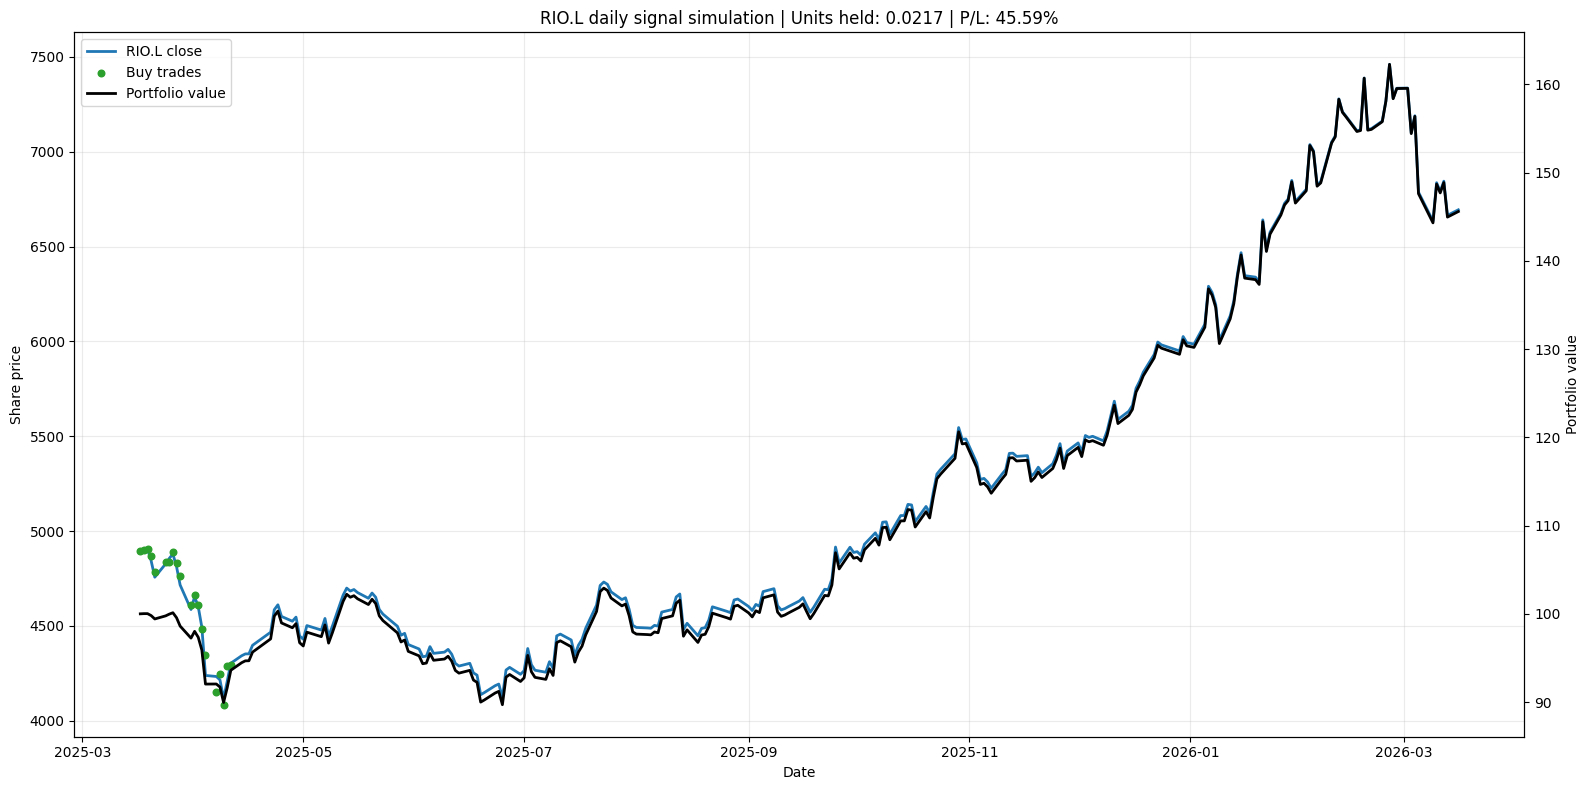

In [26]:
price_history = simulation_result["price_history"].copy()
daily_history = simulation_result["daily_history"].copy()
transactions = simulation_result["transactions"].copy()
simulation_summary = simulation_result["summary"].iloc[0]

buy_txns = transactions[transactions["action"] == "BUY"].copy()
sell_txns = transactions[transactions["action"] == "SELL"].copy()

fig, ax_price = plt.subplots(figsize=(16, 8))
ax_price.plot(
    price_history["Date"],
    price_history["Close"],
    color="#1f77b4",
    linewidth=2,
    label=f"{ticker} close",
)

if not buy_txns.empty:
    ax_price.scatter(
        buy_txns["Date"],
        buy_txns["trade_price"],
        color="#2ca02c",
        marker=".",
        s=90,
        label="Buy trades",
        zorder=5,
    )

if not sell_txns.empty:
    ax_price.scatter(
        sell_txns["Date"],
        sell_txns["trade_price"],
        color="#d62728",
        marker=".",
        s=90,
        label="Sell trades",
        zorder=5,
    )

ax_price.set_xlabel("Date")
ax_price.set_ylabel("Share price")
ax_price.grid(alpha=0.25)

ax_portfolio = ax_price.twinx()
ax_portfolio.plot(
    daily_history["Date"],
    daily_history["portfolio_value"],
    color="#000000",
    linewidth=2,
    label="Portfolio value",
)
ax_portfolio.set_ylabel("Portfolio value")

title = (
    f"{ticker} daily signal simulation | "
    f"Units held: {simulation_summary['units_held']:.4f} | "
    f"P/L: {simulation_summary['profit_loss_pct']:.2f}%"
)
ax_price.set_title(title)

handles_price, labels_price = ax_price.get_legend_handles_labels()
handles_portfolio, labels_portfolio = ax_portfolio.get_legend_handles_labels()
ax_price.legend(handles_price + handles_portfolio, labels_price + labels_portfolio, loc="upper left")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## Block 7: Daily Portfolio History


In [27]:
simulation_result["daily_history"][[
    "Date",
    "signal_text",
    "action",
    "trade_units",
    "trade_value",
    "cash_balance",
    "units_held",
    "holdings_value",
    "portfolio_value",
    "profit_loss_pct",
]]


,Date,signal_text,action,trade_units,trade_value,cash_balance,units_held,holdings_value,portfolio_value,profit_loss_pct
0,2025-03-17,WEAK BUY,BUY,0.001022,5.0,95.0,0.001022,4.997190,99.997190,-0.002810
1,2025-03-18,WEAK BUY,BUY,0.001020,5.0,90.0,0.002042,10.018639,100.018639,0.018639
2,2025-03-19,WEAK BUY,BUY,0.001019,5.0,85.0,0.003061,15.018638,100.018638,0.018638
3,2025-03-20,WEAK BUY,BUY,0.001027,5.0,80.0,0.004088,19.797312,99.797312,-0.202688
4,2025-03-21,WEAK BUY,BUY,0.001045,5.0,75.0,0.005133,24.415462,99.415462,-0.584538
...,...,...,...,...,...,...,...,...,...,...
247,2026-03-10,WEAK BUY,HOLD,0.000000,0.0,0.0,0.021750,148.704462,148.704462,48.704462
248,2026-03-11,WEAK BUY,HOLD,0.000000,0.0,0.0,0.021750,147.703964,147.703964,47.703964
249,2026-03-12,WEAK BUY,HOLD,0.000000,0.0,0.0,0.021750,148.878462,148.878462,48.878462
250,2026-03-13,WEAK BUY,HOLD,0.000000,0.0,0.0,0.021750,144.963470,144.963470,44.963470
